In [1]:
import sys
import os
sys.path.append('..')

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal.windows import hann
from scipy.ndimage import gaussian_filter1d

# Statistical texture quality meatric against cutoff frequency

In [2]:
def radial_profile(power):
    h, w = power.shape
    cy, cx = h//2, w//2

    y, x = np.indices((h, w))
    r = np.sqrt((x-cx)**2 + (y-cy)**2)

    r_int = r.astype(int)

    tbin = np.bincount(r_int.ravel(), power.ravel())
    nr = np.bincount(r_int.ravel())

    radial = tbin / np.maximum(nr, 1)

    r_vals = np.arange(len(radial))

    # correct normalization
    r_norm = r_vals / r.max()

    return r_norm, radial

In [3]:
def effective_resolution_cutoff(patch,
                                detrend_sigma=12,
                                r_min_frac=0.05,
                                tail_frac=0.85):

    patch = patch.astype(np.float32)

    # --- detrend (remove low-frequency background)
    background = gaussian_filter(patch, detrend_sigma)
    g = patch - background

    # --- apply 2D Hann window
    wy = hann(patch.shape[0])
    wx = hann(patch.shape[1])
    window = np.outer(wy, wx)
    g *= window

    # --- FFT power spectrum
    F = np.fft.fftshift(np.fft.fft2(g))
    P = np.abs(F)**2

    # --- radial mean spectrum
    r, prof = radial_profile(P)
    n = len(prof)

    # --- estimate noise floor from tail
    tail_start = int(tail_frac * n)
    N0 = np.median(prof[tail_start:])

    # corrected spectrum
    prof_corr = np.maximum(prof - N0, 0)

    # smooth
    prof_corr = gaussian_filter1d(prof_corr, 2)

    # ignore center
    start = int(r_min_frac * n)

    # relative threshold
    threshold = 0.05 * prof_corr[start:].max()

    idx = np.where(prof_corr > threshold)[0]
    idx = idx[idx >= start]

    if len(idx) == 0:
        fc = 0
    else:
        fc = r[idx.max()]

    return fc, r, prof, prof_corr

In [4]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from scipy.stats import entropy as scipy_entropy
from skimage.feature import graycomatrix, graycoprops

base = "data/patch_samples"
groups = ["spatial_high", "spatial_low", "spectral_high", "spectral_low"]

def local_variance(img):
    return np.var(img.astype(np.float32))

def shannon_entropy_simple(img, bins=256):
    hist, _ = np.histogram(img.ravel(), bins=bins, range=(0, 256), density=True)
    hist = hist[hist > 0]
    return scipy_entropy(hist, base=2)

def glcm_features(img):
    # quantize to fewer levels for stable GLCM
    img_q = (img.astype(np.float32) / 32).astype(np.uint8)  # 8 levels
    glcm = graycomatrix(
        img_q,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=8,
        symmetric=True,
        normed=True
    )
    contrast = graycoprops(glcm, "contrast").mean()
    homogeneity = graycoprops(glcm, "homogeneity").mean()
    energy = graycoprops(glcm, "energy").mean()
    return contrast, homogeneity, energy

rows = []

for g in groups:
    path = os.path.join(base, g)
    for fname in os.listdir(path):
        if not fname.endswith(".png"):
            continue

        patch = np.array(Image.open(os.path.join(path, fname)).convert("L"))
        fc, _, _, _ = effective_resolution_cutoff(patch)

        var_ = local_variance(patch)
        ent_ = shannon_entropy_simple(patch)
        contrast, homogeneity, energy = glcm_features(patch)

        rows.append({
            "group": g,
            "file": fname,
            "fc": fc,
            "variance": var_,
            "entropy": ent_,
            "glcm_contrast": contrast,
            "glcm_homogeneity": homogeneity,
            "glcm_energy": energy,
        })

df = pd.DataFrame(rows)
df.head()

,group,file,fc,variance,entropy,glcm_contrast,glcm_homogeneity,glcm_energy
0,spatial_high,patch_0206497_r39168_c41728.png,0.182301,1820.621948,7.302658,0.736973,0.732816,0.273320
1,spatial_high,patch_0295640_r53376_c70400.png,0.265165,1666.375732,7.243598,0.747348,0.725230,0.285084
2,spatial_high,patch_0203950_r38784_c42624.png,0.215447,1577.735474,7.193881,0.686396,0.738293,0.285681
3,spatial_high,patch_0197724_r37888_c36352.png,0.226495,1460.152588,7.182790,0.722175,0.732866,0.289181
4,spatial_high,patch_0167295_r33536_c5504.png,0.226495,1775.970703,7.230258,0.714706,0.739297,0.313094


In [5]:
features = ["variance", "entropy", "glcm_contrast", "glcm_homogeneity", "glcm_energy"]

for feat in features:
    corr = df["fc"].corr(df[feat])
    print(f"{feat}: corr with fc = {corr:.3f}")

variance: corr with fc = -0.522
entropy: corr with fc = -0.504
glcm_contrast: corr with fc = -0.290
glcm_homogeneity: corr with fc = 0.302
glcm_energy: corr with fc = 0.458


In [6]:
df["fc_bin"] = pd.qcut(df["fc"], q=3, labels=["low_fc", "mid_fc", "high_fc"])

summary = df.groupby("fc_bin")[features].agg(["mean", "std"])
summary

/tmp/ipykernel_9410/1356288604.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("fc_bin")[features].agg(["mean", "std"])


variance                entropy           glcm_contrast            \
                mean          std      mean       std          mean       std   
fc_bin                                                                          
low_fc   6047.880371  4125.961914  5.398306  1.641407      0.205370  0.248190   
mid_fc   1350.703491  1237.766602  5.145824  2.764679      0.440149  0.369314   
high_fc    67.193275   287.399658  1.922810  1.127828      0.017270  0.095430   

        glcm_homogeneity           glcm_energy            
                    mean       std        mean       std  
fc_bin                                                    
low_fc          0.923691  0.083648    0.625423  0.222341  
mid_fc          0.842294  0.132010    0.568685  0.360584  
high_fc         0.993597  0.033653    0.982807  0.091326

In [7]:
cv_summary = {}
for feat in features:
    grp = df.groupby("fc_bin")[feat]
    cv_summary[feat] = (grp.std() / (grp.mean().abs() + 1e-8)).to_dict()

cv_summary

/tmp/ipykernel_9410/1409371104.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("fc_bin")[feat]
/tmp/ipykernel_9410/1409371104.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("fc_bin")[feat]


{'variance': {'low_fc': 0.6822161674499512,
  'mid_fc': 0.916386604309082,
  'high_fc': 4.2772088050842285},
 'entropy': {'low_fc': 0.30405958030503993,
  'mid_fc': 0.53726662505432,
  'high_fc': 0.586551946943266},
 'glcm_contrast': {'low_fc': 1.2085019054214459,
  'mid_fc': 0.8390655559956837,
  'high_fc': 5.525766266661673},
 'glcm_homogeneity': {'low_fc': 0.09055800588995605,
  'mid_fc': 0.15672683293429146,
  'high_fc': 0.033870014019213204},
 'glcm_energy': {'low_fc': 0.35550438251603617,
  'mid_fc': 0.6340673369491304,
  'high_fc': 0.09292401975503878}}

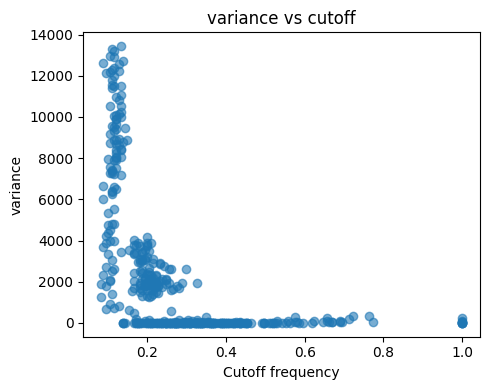

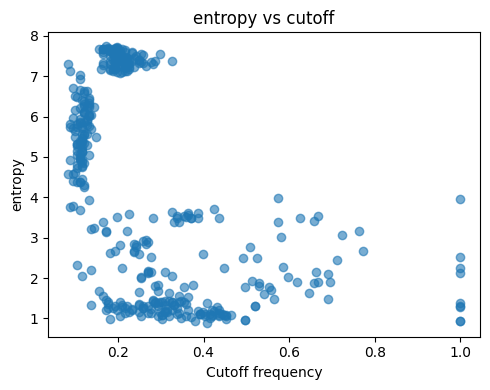

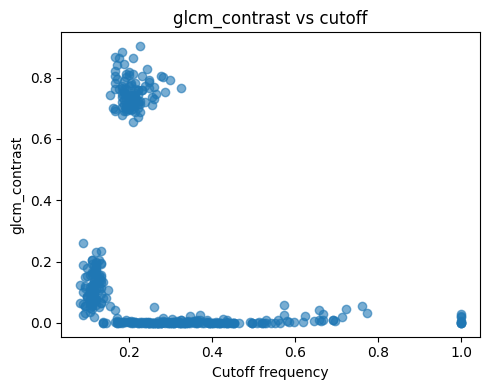

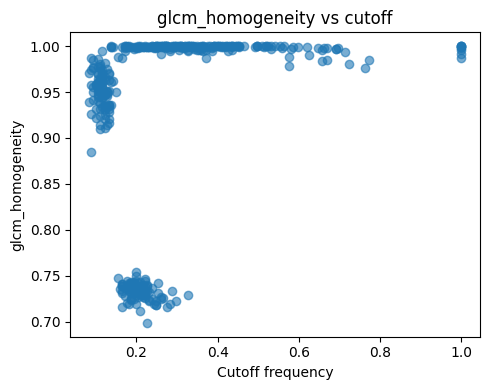

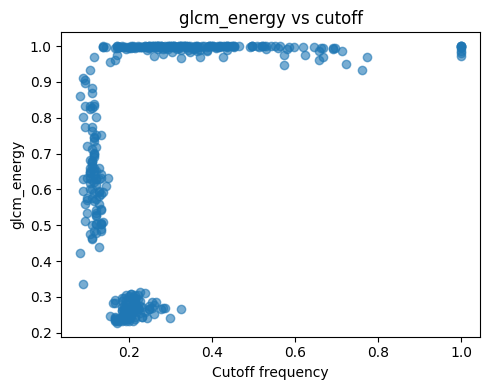

In [8]:
import matplotlib.pyplot as plt

for feat in features:
    plt.figure(figsize=(5,4))
    plt.scatter(df["fc"], df[feat], alpha=0.6)
    plt.xlabel("Cutoff frequency")
    plt.ylabel(feat)
    plt.title(f"{feat} vs cutoff")
    plt.tight_layout()
    plt.show()

# Simple segmentation

In [9]:
from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects
from skimage.measure import label

def naive_segment_count(img, blur_sigma=0.0, min_size=6, dark_objects=True):
    x = img.astype(np.float32)

    if blur_sigma > 0:
        x = gaussian_filter(x, blur_sigma)

    thr = threshold_otsu(x)

    if dark_objects:
        mask = x < thr
    else:
        mask = x > thr

    mask = remove_small_objects(mask, min_size=min_size)

    lbl = label(mask)
    count = lbl.max()
    frac = mask.mean()

    return count, frac, mask

In [10]:
blur_levels = [0, 1, 2, 3]
rows_seg = []

for g in groups:
    path = os.path.join(base, g)
    for fname in os.listdir(path):
        if not fname.endswith(".png"):
            continue

        patch = np.array(Image.open(os.path.join(path, fname)).convert("L"))
        fc, _, _, _ = effective_resolution_cutoff(patch)

        counts = []
        fracs = []

        for s in blur_levels:
            cnt, frac, _ = naive_segment_count(patch, blur_sigma=s, min_size=6, dark_objects=True)
            counts.append(cnt)
            fracs.append(frac)

        rows_seg.append({
            "group": g,
            "file": fname,
            "fc": fc,
            "count_mean": np.mean(counts),
            "count_std": np.std(counts),
            "count_range": np.max(counts) - np.min(counts),
            "count_cv": np.std(counts) / (np.mean(counts) + 1e-8),
            "frac_mean": np.mean(fracs),
            "frac_std": np.std(fracs),
            "counts": counts,
        })

df_seg = pd.DataFrame(rows_seg)
df_seg.head()

,group,file,fc,count_mean,count_std,count_range,count_cv,frac_mean,frac_std,counts
0,spatial_high,patch_0206497_r39168_c41728.png,0.182301,79.50,33.648923,88,0.423257,0.449036,0.025433,"[125, 96, 60, 37]"
1,spatial_high,patch_0295640_r53376_c70400.png,0.265165,37.25,15.864662,38,0.425897,0.598038,0.014331,"[54, 51, 28, 16]"
2,spatial_high,patch_0203950_r38784_c42624.png,0.215447,84.75,36.306852,95,0.428399,0.371647,0.012974,"[139, 95, 61, 44]"
3,spatial_high,patch_0197724_r37888_c36352.png,0.226495,44.50,23.070544,61,0.518439,0.573967,0.025214,"[74, 57, 34, 13]"
4,spatial_high,patch_0167295_r33536_c5504.png,0.226495,89.25,58.537915,151,0.655887,0.354660,0.052396,"[176, 108, 48, 25]"


In [11]:
for feat in ["count_std", "count_range", "count_cv", "frac_std"]:
    corr = df_seg["fc"].corr(df_seg[feat])
    print(f"{feat}: corr with fc = {corr:.3f}")

count_std: corr with fc = 0.381
count_range: corr with fc = 0.384
count_cv: corr with fc = 0.212
frac_std: corr with fc = 0.205


In [12]:
df_seg["fc_bin"] = pd.qcut(df_seg["fc"], q=3, labels=["low_fc", "mid_fc", "high_fc"])

df_seg.groupby("fc_bin")[["count_std", "count_range", "count_cv", "frac_std"]].agg(["mean", "std"])

/tmp/ipykernel_9410/11264486.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_seg.groupby("fc_bin")[["count_std", "count_range", "count_cv", "frac_std"]].agg(["mean", "std"])


count_std            count_range              count_cv            \
              mean        std        mean         std      mean       std   
fc_bin                                                                      
low_fc    8.145753  19.396342   20.218978   46.810902  0.287824  0.270042   
mid_fc   36.805020  35.634506   93.717557   89.814790  0.517576  0.272204   
high_fc  56.360890  51.977331  142.719697  129.449882  0.498939  0.460928   

         frac_std            
             mean       std  
fc_bin                       
low_fc   0.010513  0.022040  
mid_fc   0.035889  0.032327  
high_fc  0.035035  0.034611

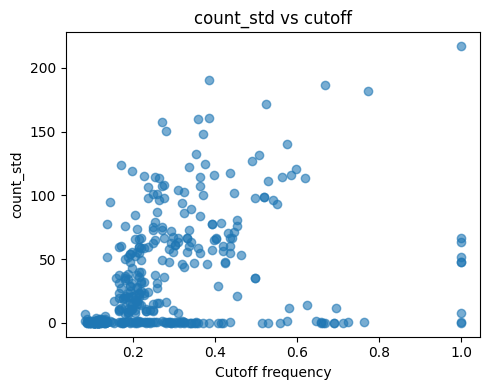

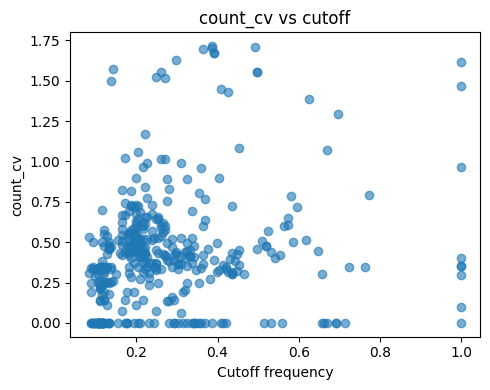

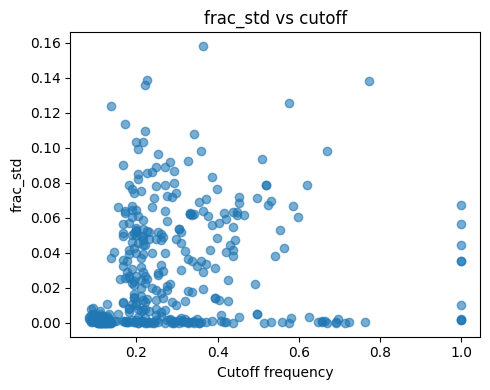

In [13]:
for feat in ["count_std", "count_cv", "frac_std"]:
    plt.figure(figsize=(5,4))
    plt.scatter(df_seg["fc"], df_seg[feat], alpha=0.6)
    plt.xlabel("Cutoff frequency")
    plt.ylabel(feat)
    plt.title(f"{feat} vs cutoff")
    plt.tight_layout()
    plt.show()